In [1]:
import os
import sys
import hashlib
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
from model import ParticleTransformerKD  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'baseline_offline_vs_smeared_hlt'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
SHARED_BASELINE_DIR = os.path.join(MODULE_DIR, 'runs', 'shared_offline_hlt_baselines')
SHARED_BASELINE_CKPT_DIR = os.path.join(SHARED_BASELINE_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(SHARED_BASELINE_CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(TAGGING_DIR, 'test.h5'),
    'load_shared_baselines': True,
    'n_jets': 200000,
    'max_particles': 100,
    'feature_kind': '7d',
    'hlt_effects': {
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 0.5,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'visual': {
        'n_scatter': 100000,
        'n_bins': 20,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'training': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['tagger']['input_dim'] = len(feat_names)

print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)

Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt
Feature kind: 7d feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']


In [2]:
# Load raw constituents
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164


In [3]:
# Build offline and smeared-HLT views
hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])

_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

print('Offline/HLT:', off_const.shape, hlt_const.shape)
print('Avg tokens per jet | offline:', float(off_mask.sum(axis=1).mean()))
print('Avg tokens per jet | hlt    :', float(hlt_mask.sum(axis=1).mean()))
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

print('Features:', feat_off.shape, feat_hlt.shape, 'kind:', CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

Offline/HLT: (200000, 100, 4) (200000, 100, 4)
Avg tokens per jet | offline: 54.29243
Avg tokens per jet | hlt    : 54.29243
Mask identical: True
Features: (200000, 100, 7) (200000, 100, 7) kind: 7d
Split: train=140,000 val=30,000 test=30,000


In [4]:
# Standardize using offline train statistics
feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)

feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

print('Standardization done.')
print('Means:', np.round(feat_means, 4))
print('Stds :', np.round(feat_stds, 4))
print('Common-mask fraction:', float(common_mask.mean()))

Standardization done.
Means: [-2.0000e-04 -1.0000e-04  8.7940e+00  9.0840e+00 -5.2585e+00 -5.2701e+00
  2.2250e-01]
Stds : [0.2121 0.2173 1.5182 1.5217 1.4919 1.4935 0.2067]
Common-mask fraction: 0.5429243


In [5]:
# Token-level comparison tensors
x_std = feat_hlt_std[test_idx]
y_std = feat_off_std[test_idx]
mask_np = common_mask[test_idx]

print('Test tensors:', x_std.shape, y_std.shape, mask_np.shape)
print('Valid tokens in test split:', int(mask_np.sum()))

Test tensors: (30000, 100, 7) (30000, 100, 7) (30000, 100)
Valid tokens in test split: 1630900


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_dEta.png


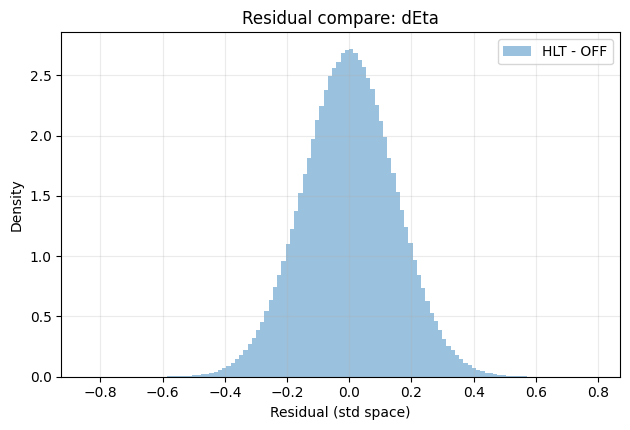

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_dPhi.png


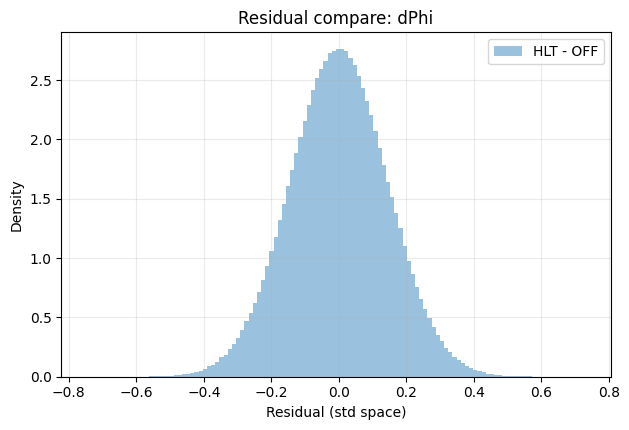

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_log_pt.png


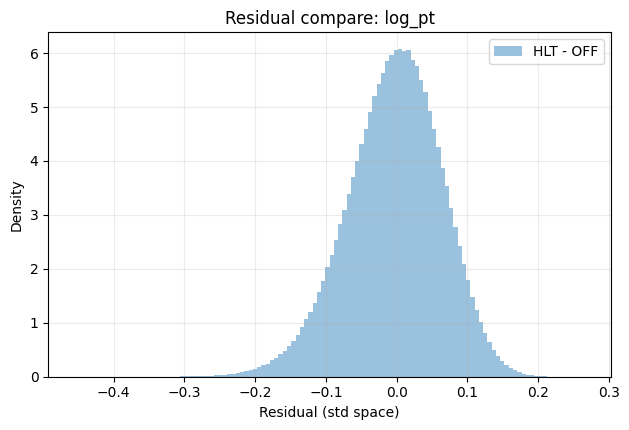

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_log_E.png


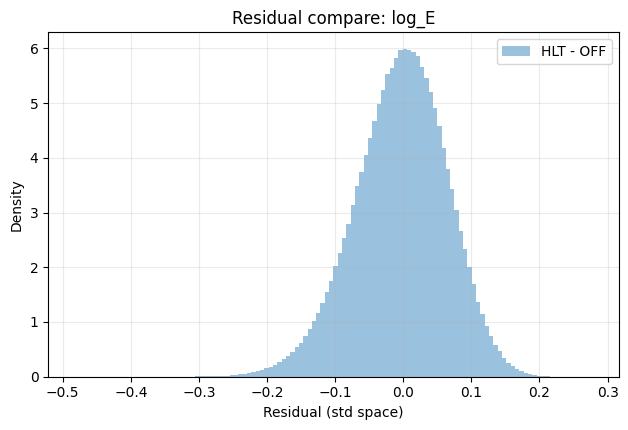

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_log_pt_rel.png


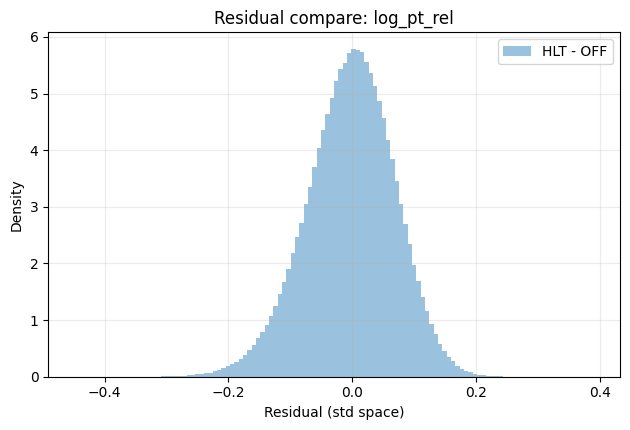

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_log_E_rel.png


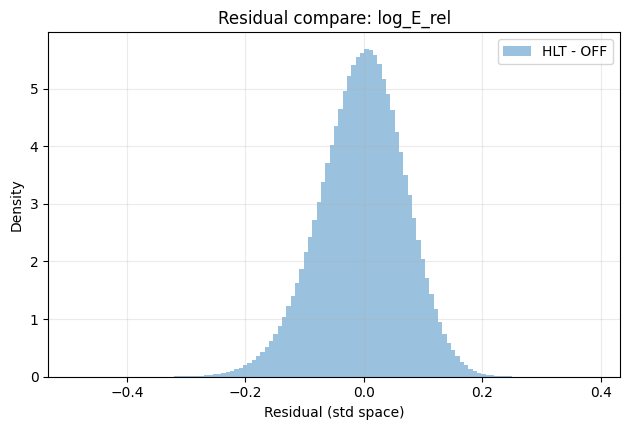

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_resid_smeared_hlt_vs_offline_dR.png


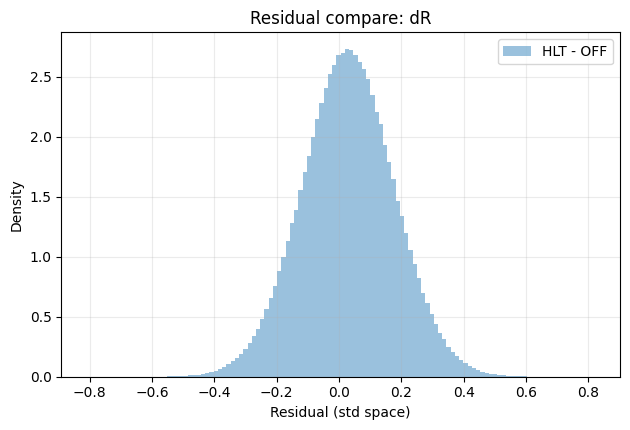

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_dEta.png


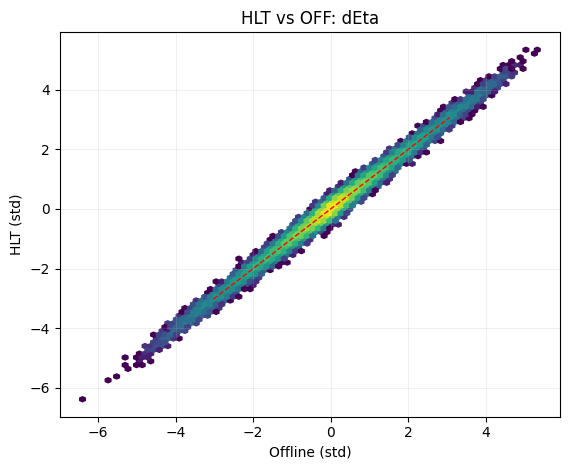

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_dPhi.png


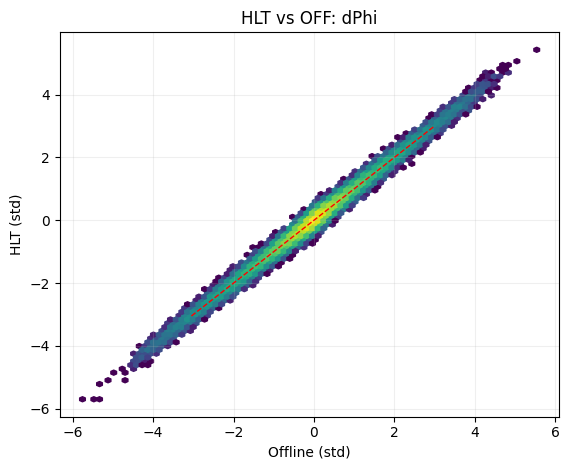

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_log_pt.png


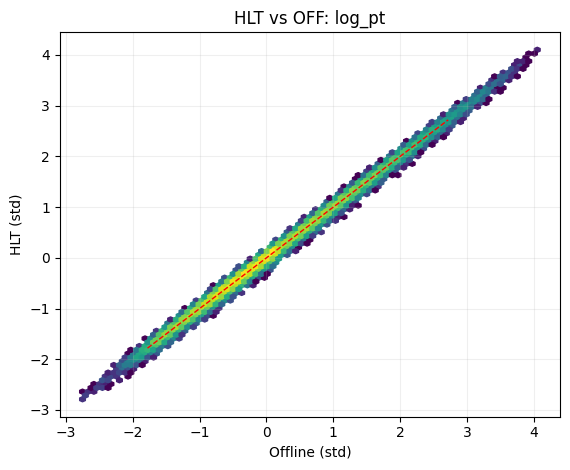

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_log_E.png


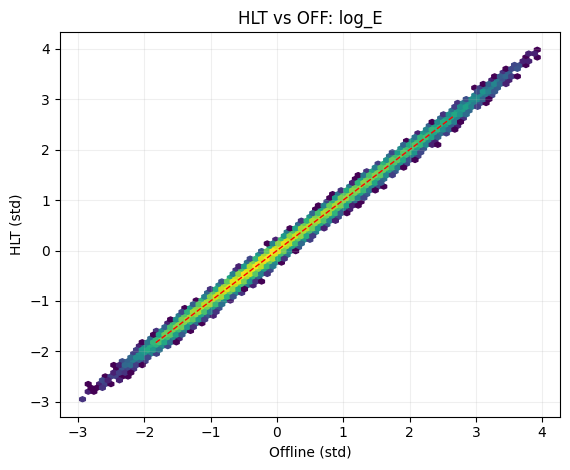

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_log_pt_rel.png


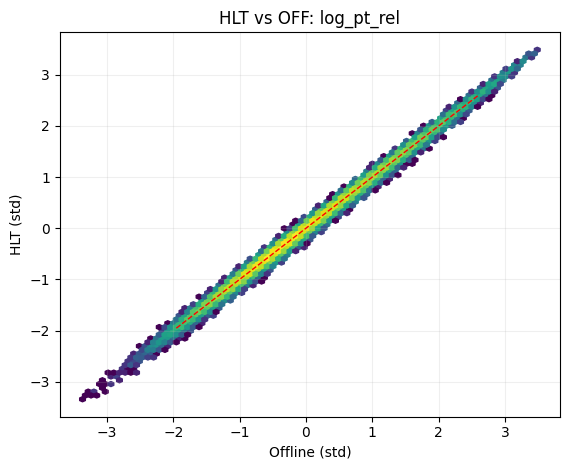

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_log_E_rel.png


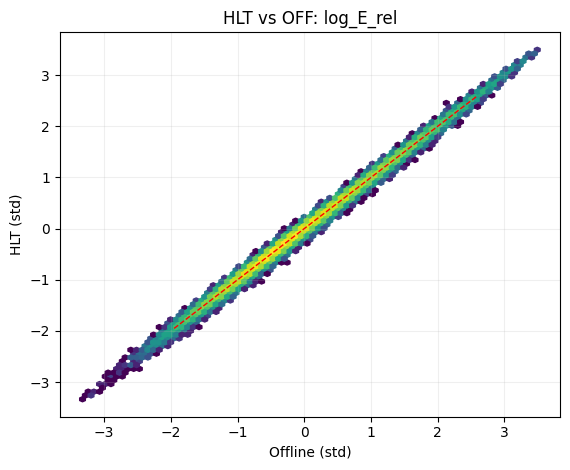

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_scatter_smeared_hlt_vs_offline_dR.png


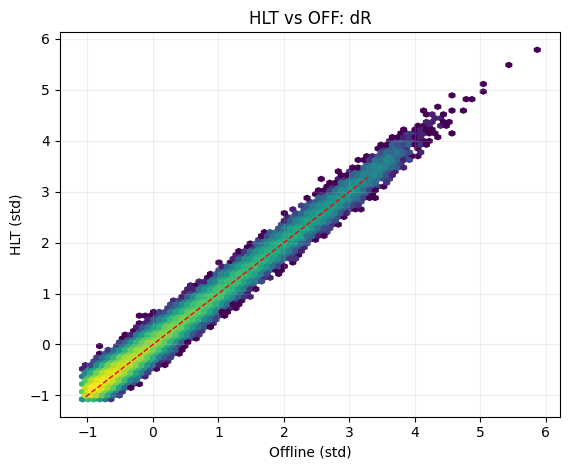


Metrics summary (std space) | n_tokens=1630900
feature	bias	mae	rmse	abs_p50	abs_p90	abs_p99
dEta	-0.000556	0.118285	0.148658	0.099482	0.244542	0.385490
dPhi	-0.000172	0.115474	0.145006	0.097246	0.238573	0.375467
log_pt	-0.003360	0.052877	0.066770	0.044331	0.108811	0.177613
log_E	-0.003796	0.053589	0.067663	0.044937	0.110348	0.179946
log_pt_rel	-0.002749	0.056079	0.070901	0.046882	0.115897	0.188754
log_E_rel	-0.003435	0.056860	0.071879	0.047528	0.117525	0.191154
dR	0.028985	0.120490	0.151625	0.101127	0.249538	0.394740
Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_dEta.png


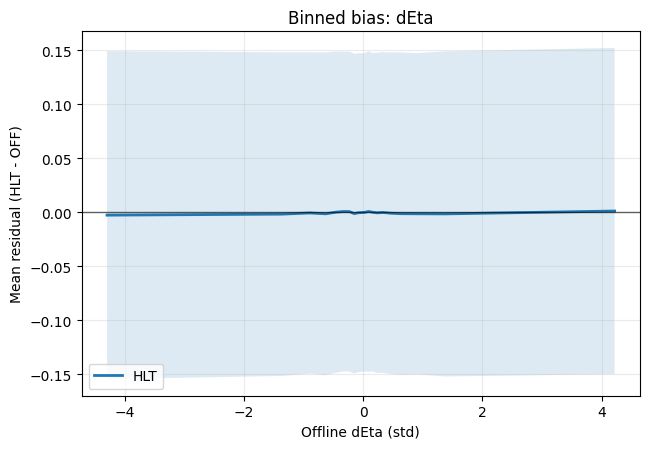

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_dPhi.png


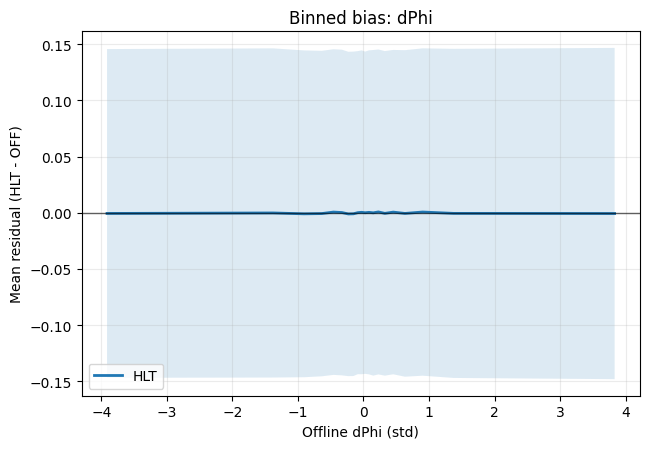

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_log_pt.png


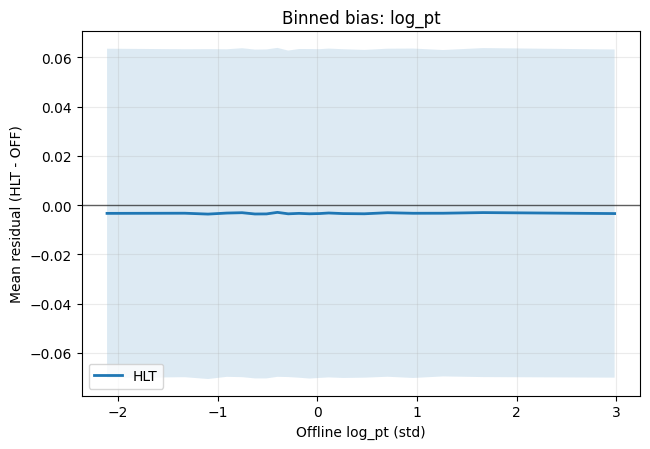

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_log_E.png


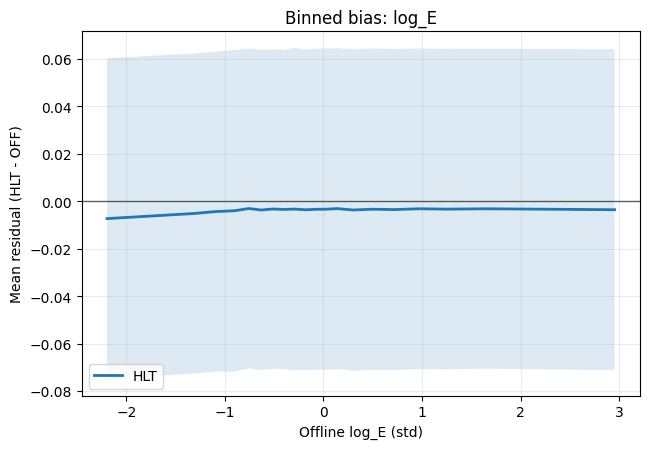

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_log_pt_rel.png


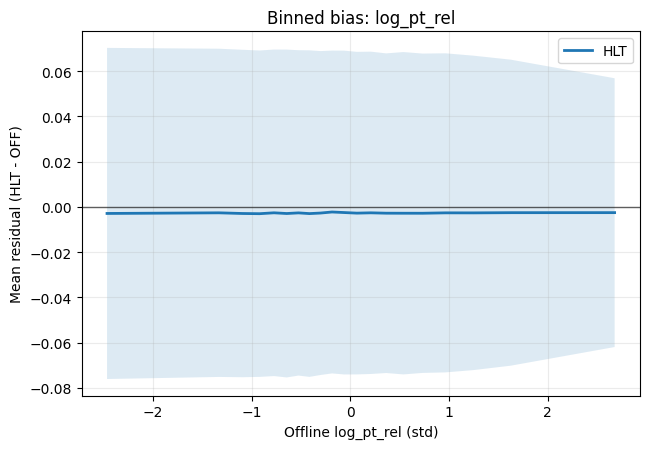

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_log_E_rel.png


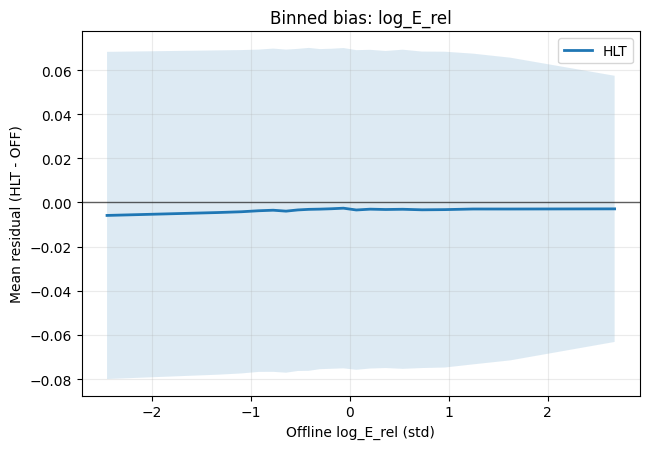

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\baseline_offline_vs_smeared_hlt\figs\baseline_bias_smeared_hlt_vs_offline_dR.png


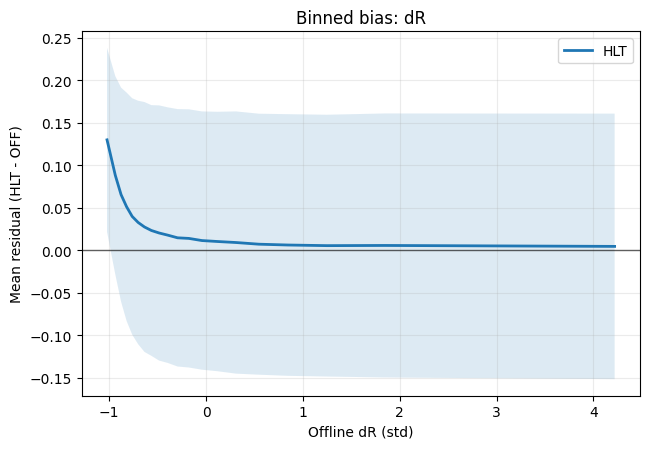

In [6]:
# Visualizations: HLT vs offline
N_scatter = int(CONFIG['visual']['n_scatter'])
N_BINS = int(CONFIG['visual']['n_bins'])

for i, name in enumerate(feat_names):
    x_i = x_std[..., i][mask_np]
    y_i = y_std[..., i][mask_np]
    r_hlt = x_i - y_i

    if name == 'dPhi':
        sc = float(feat_stds[i])
        r_hlt = tool.wrap_dphi_np(r_hlt * sc) / sc

    plt.figure(figsize=(6.4, 4.4))
    plt.hist(r_hlt, bins=120, density=True, alpha=0.45, label='HLT - OFF')
    plt.title(f'Residual compare: {name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'baseline_resid_smeared_hlt_vs_offline_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

sel = np.where(mask_np.reshape(-1))[0]
if sel.size > N_scatter:
    sel = np.random.RandomState(0).choice(sel, size=N_scatter, replace=False)

for i, name in enumerate(feat_names):
    y_flat = y_std[..., i].reshape(-1)[sel]
    x_flat = x_std[..., i].reshape(-1)[sel]
    lo = np.percentile(np.concatenate([y_flat, x_flat]), 1)
    hi = np.percentile(np.concatenate([y_flat, x_flat]), 99)

    plt.figure(figsize=(5.8, 4.8))
    plt.hexbin(y_flat, x_flat, gridsize=80, bins='log', mincnt=1)
    plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
    plt.xlabel('Offline (std)')
    plt.ylabel('HLT (std)')
    plt.title(f'HLT vs OFF: {name}')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'baseline_scatter_smeared_hlt_vs_offline_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


def _metrics(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {'bias': np.nan, 'mae': np.nan, 'rmse': np.nan, 'p50': np.nan, 'p90': np.nan, 'p99': np.nan}
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'p50': float(np.quantile(abs_r, 0.50)),
        'p90': float(np.quantile(abs_r, 0.90)),
        'p99': float(np.quantile(abs_r, 0.99)),
    }

print()
print('=' * 80)
print(f'Metrics summary (std space) | n_tokens={int(mask_np.sum())}')
print('=' * 80)
print('\t'.join(['feature', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']))
for i, name in enumerate(feat_names):
    r = (x_std[..., i] - y_std[..., i])[mask_np]
    if name == 'dPhi':
        sc = float(feat_stds[i])
        r = tool.wrap_dphi_np(r * sc) / sc
    mm = _metrics(r)
    print('	'.join([
        name,
        f"{mm['bias']:.6f}",
        f"{mm['mae']:.6f}",
        f"{mm['rmse']:.6f}",
        f"{mm['p50']:.6f}",
        f"{mm['p90']:.6f}",
        f"{mm['p99']:.6f}",
    ]))

for i, name in enumerate(feat_names):
    y_flat = y_std[..., i][mask_np]
    r_flat = (x_std[..., i] - y_std[..., i])[mask_np]
    if name == 'dPhi':
        sc = float(feat_stds[i])
        r_flat = tool.wrap_dphi_np(r_flat * sc) / sc

    if y_flat.size < 1000:
        continue
    edges = np.unique(np.quantile(y_flat, np.linspace(0.0, 1.0, N_BINS + 1)))
    if edges.size < 3:
        continue
    centers = 0.5 * (edges[:-1] + edges[1:])
    means, stds = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        inb = (y_flat >= lo) & (y_flat < hi)
        if not np.any(inb):
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(float(np.mean(r_flat[inb])))
            stds.append(float(np.std(r_flat[inb])))
    means = np.asarray(means)
    stds = np.asarray(stds)

    plt.figure(figsize=(6.6, 4.6))
    plt.plot(centers, means, lw=2, label='HLT')
    plt.fill_between(centers, means - stds, means + stds, alpha=0.15)
    plt.axhline(0.0, color='k', lw=1, alpha=0.6)
    plt.xlabel(f'Offline {name} (std)')
    plt.ylabel('Mean residual (HLT - OFF)')
    plt.title(f'Binned bias: {name}')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'baseline_bias_smeared_hlt_vs_offline_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

In [ ]:
# Downstream tagger training setup: offline teacher vs HLT student
train_ds = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

BS = int(CONFIG['training']['batch_size'])
train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BS, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BS, shuffle=False)

TAGGER_CFG = dict(CONFIG['tagger'])
TRAIN_CFG = dict(CONFIG['training'])
KD_CFG = {
    'kd': {
        'temperature': 2.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0.05,
    }
}
SHARED_TAG_CKPT_DIR = SHARED_BASELINE_CKPT_DIR

_SPLIT_DIGEST = hashlib.sha1(np.asarray(train_idx, dtype=np.int64).tobytes()).hexdigest()[:12]
_BASELINE_META = {
    'feature_kind': str(CONFIG['feature_kind']),
    'tagger_cfg': dict(TAGGER_CFG),
    'kd_cfg': dict(KD_CFG),
    # 'split_digest': str(_SPLIT_DIGEST),
    # 'data_path': str(CONFIG['data_path']),
    'n_jets': int(CONFIG['n_jets']),
    'max_particles': int(CONFIG['max_particles']),
    'hlt_effects': dict(CONFIG['hlt_effects']),
}


def _make_opt(model):
    opt = torch.optim.AdamW(model.parameters(), lr=float(TRAIN_CFG['lr']), weight_decay=float(TRAIN_CFG['weight_decay']))
    sch = tool.get_scheduler(opt, int(TRAIN_CFG['warmup_epochs']), int(TRAIN_CFG['epochs']))
    return opt, sch


def _try_load_shared(model, ckpt_path: str) -> bool:
    if not bool(CONFIG.get('load_shared_baselines', True)):
        return False
    if not os.path.isfile(ckpt_path):
        return False
    obj = torch.load(ckpt_path, map_location='cpu')
    if isinstance(obj, dict) and 'meta' in obj:
        meta = obj.get('meta') or {}
        for k in ['feature_kind', 'tagger_cfg', 'n_jets', 'max_particles', 'hlt_effects']:
            if str(meta.get(k)) != str(_BASELINE_META.get(k)):
                print('Skip shared checkpoint (meta mismatch):', ckpt_path)
                return False
    state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
    model.load_state_dict(state)
    print('Loaded shared checkpoint:', ckpt_path)
    return True


def _save_shared(model, ckpt_path: str):
    payload = {
        'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
        'meta': dict(_BASELINE_META),
    }
    torch.save(payload, ckpt_path)
    print('Saved shared checkpoint:', ckpt_path)


def _train_standard(name: str, model, feat_key: str, mask_key: str):
    opt, sch = _make_opt(model)
    best_auc, best_state, no_imp = 0.0, None, 0
    for ep in range(1, int(TRAIN_CFG['epochs']) + 1):
        loss, _ = tool.train_standard(model, train_loader, opt, device, feat_key, mask_key)
        sch.step()
        val_auc, _, _ = tool.evaluate(model, val_loader, device, feat_key, mask_key)
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(f'[{name}] ep={ep:03d} train_loss={loss:.5f} val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}')
        if no_imp >= int(TRAIN_CFG['patience']):
            print(f'[{name}] Early stopping')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def _train_kd(name: str, student, teacher):
    opt, sch = _make_opt(student)
    best_auc, best_state, no_imp = 0.0, None, 0

    T = float(KD_CFG['kd']['temperature'])
    a_kd = float(KD_CFG['kd']['alpha_kd'])
    a_attn = float(KD_CFG['kd']['alpha_attn'])
    a_hard = 1.0 - a_kd

    for ep in range(1, int(TRAIN_CFG['epochs']) + 1):
        student.train()
        teacher.eval()

        sums = {
            'total': 0.0,
            'hard': 0.0,
            'kd': 0.0,
            'attn': 0.0,
            'hard_w': 0.0,
            'kd_w': 0.0,
            'attn_w': 0.0,
        }
        preds, labs = [], []
        n = 0

        for batch in train_loader:
            x_hlt = batch['hlt'].to(device)
            x_off = batch['off'].to(device)
            m_hlt = batch['mask_hlt'].to(device)
            m_off = batch['mask_off'].to(device)
            y = batch['label'].to(device)
            w = batch['weight'].to(device)

            with torch.no_grad():
                t_logits, t_attn = teacher(x_off, m_off, return_attention=True)
                t_logits = t_logits.squeeze(-1)

            opt.zero_grad(set_to_none=True)
            s_logits, s_attn = student(x_hlt, m_hlt, return_attention=True)
            s_logits = s_logits.squeeze(-1)

            loss_kd = tool.kd_loss(s_logits, t_logits, T)
            loss_hard = torch.nn.functional.binary_cross_entropy_with_logits(s_logits, y, weight=w)
            loss_attn = tool.attn_loss(s_attn, t_attn, m_hlt, m_off)

            loss_hard_w = a_hard * loss_hard
            loss_kd_w = a_kd * loss_kd
            loss_attn_w = a_attn * loss_attn
            loss = loss_hard_w + loss_kd_w + loss_attn_w

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            opt.step()

            bs = int(y.shape[0])
            sums['total'] += float(loss.item()) * bs
            sums['hard'] += float(loss_hard.item()) * bs
            sums['kd'] += float(loss_kd.item()) * bs
            sums['attn'] += float(loss_attn.item()) * bs
            sums['hard_w'] += float(loss_hard_w.item()) * bs
            sums['kd_w'] += float(loss_kd_w.item()) * bs
            sums['attn_w'] += float(loss_attn_w.item()) * bs
            n += bs

            preds.extend(torch.sigmoid(s_logits).detach().cpu().numpy().flatten())
            labs.extend(y.detach().cpu().numpy().flatten())

        train_terms = {k: v / max(1, n) for k, v in sums.items()}
        train_auc = float(tool.roc_auc_score(labs, preds))

        sch.step()
        val_auc, _, _ = tool.evaluate(student, val_loader, device, 'hlt', 'mask_hlt')
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(
                f'[{name}] ep={ep:03d} '
                f'train_total={train_terms["total"]:.5f} '
                f'train_hard={train_terms["hard"]:.5f} '
                f'train_kd={train_terms["kd"]:.5f} '
                f'train_attn={train_terms["attn"]:.5f} '
                f'train_hard_w={train_terms["hard_w"]:.5f} '
                f'train_kd_w={train_terms["kd_w"]:.5f} '
                f'train_attn_w={train_terms["attn_w"]:.5f} '
                f'train_auc={train_auc:.5f} '
                f'val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}'
            )
        if no_imp >= int(TRAIN_CFG['patience']):
            print(f'[{name}] Early stopping')
            break
    if best_state is not None:
        student.load_state_dict(best_state)
    return student

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loaded shared checkpoint: d:\PracticeTagging\tagging\pure_unsmear\runs\shared_offline_hlt_baselines\ckpts\teacher_offline.pt
Loaded shared checkpoint: d:\PracticeTagging\tagging\pure_unsmear\runs\shared_offline_hlt_baselines\ckpts\student_hlt.pt
[Student(HLT)+KD] ep=001 train_total=0.64305 train_hard=0.55049 train_kd=2.39605 train_attn=0.05690 train_hard_w=0.52296 train_kd_w=0.11980 train_attn_w=0.00028 train_auc=0.80773 val_auc=0.85008 best=0.85008 no_imp=0
[Student(HLT)+KD] ep=002 train_total=0.59019 train_hard=0.50095 train_kd=2.28192 train_attn=0.03676 train_hard_w=0.47591 train_kd_w=0.11410 train_attn_w=0.00018 train_auc=0.85050 val_auc=0.86470 best=0.86470 no_imp=0
[Student(HLT)+KD] ep=004 train_total=0.52350 train_hard=0.43794 train_kd=2.14677 train_attn=0.02374 train_hard_w=0.41604 train_kd_w=0.10734 train_attn_w=0.00012 train_auc=0.89111 val_auc=0.89359 best=0.89359 no_imp=0
[Student(HLT)+KD] ep=006 train_total=0.49981 train_hard=0.41538 train_kd=2.10195 train_attn=0.02033 tra

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\PracticeTagging\\tagging\\pure_unsmear\\runs\\baseline_offline_vs_smeared_hlt\\figs\\baseline_roc_offline_vs_smeared_hlt.png'

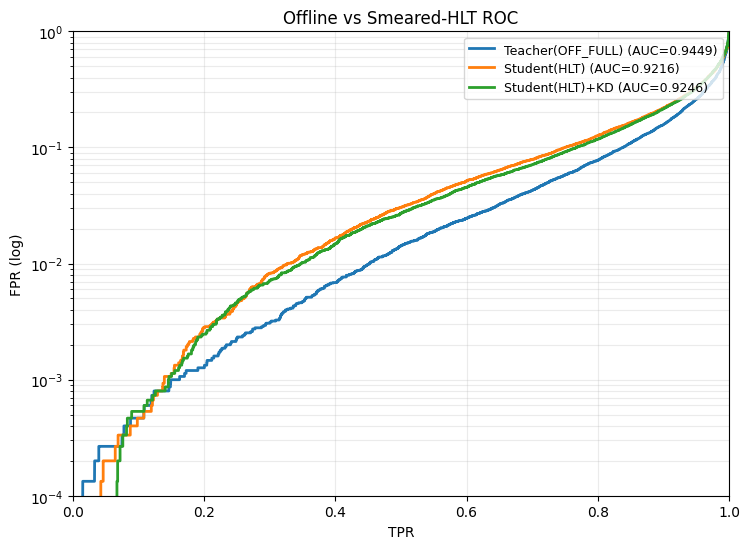

In [17]:
# Train / load offline teacher, HLT student, and HLT+KD student, then evaluate ROC
teacher = ParticleTransformerKD(**TAGGER_CFG).to(device)
teacher_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'teacher_offline.pt')
if not _try_load_shared(teacher, teacher_ckpt):
    teacher = _train_standard('Teacher(OFF_FULL)', teacher, 'off', 'mask_off')
    _save_shared(teacher, teacher_ckpt)

student_hlt = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'student_hlt.pt')
if not _try_load_shared(student_hlt, student_ckpt):
    student_hlt = _train_standard('Student(HLT)', student_hlt, 'hlt', 'mask_hlt')
    _save_shared(student_hlt, student_ckpt)

student_hlt_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_kd_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'student_hlt_kd.pt')
# if not _try_load_shared(student_hlt_kd, student_kd_ckpt):
if True:
    student_hlt_kd = _train_kd('Student(HLT)+KD', student_hlt_kd, teacher)
    _save_shared(student_hlt_kd, student_kd_ckpt)

auc_teacher, p_teacher, y_true = tool.evaluate(teacher, test_loader, device, 'off', 'mask_off')
auc_hlt, p_hlt, _ = tool.evaluate(student_hlt, test_loader, device, 'hlt', 'mask_hlt')
auc_hlt_kd, p_hlt_kd, _ = tool.evaluate(student_hlt_kd, test_loader, device, 'hlt', 'mask_hlt')

print(f'Teacher(OFF_FULL) AUC={auc_teacher:.5f}')
print(f'Student(HLT) AUC={auc_hlt:.5f}')
print(f'Student(HLT)+KD AUC={auc_hlt_kd:.5f}')

curves = {
    'Teacher(OFF_FULL)': (p_teacher, y_true, auc_teacher),
    'Student(HLT)': (p_hlt, y_true, auc_hlt),
    'Student(HLT)+KD': (p_hlt_kd, y_true, auc_hlt_kd),
}

plt.figure(figsize=(7.6, 5.6))
for name, (p, y, aucv) in curves.items():
    fpr, tpr, _ = tool.compute_roc(y, p)
    plt.semilogy(tpr, np.clip(fpr, 1e-6, 1.0), lw=2, label=f'{name} (AUC={aucv:.4f})')

plt.xlabel('TPR')
plt.ylabel('FPR (log)')
plt.title('Offline vs Smeared-HLT ROC')
plt.grid(True, which='both', alpha=0.25)
plt.legend(loc='upper right', fontsize=9)
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
out = os.path.join(FIG_DIR, 'baseline_roc_offline_vs_smeared_hlt.png')
plt.tight_layout()
plt.savefig(out, dpi=170, bbox_inches='tight')
print('Saved figure:', out)
plt.show()